In [1]:
from pathlib import Path
import os
import glob

import pandas as pd
import geopandas as gpd                          
import numpy as np
import xarray as xr
from scipy import sparse


import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
from cartopy.io import shapereader   



from climada.hazard import TCTracks
from climada.hazard import Centroids
from climada.hazard import TropCyclone
from climada.util.plot import plot_from_gdf


In [2]:
############################################################################################################
# below we use TC Track data (txt files)
############################################################################################################

In [3]:
tracks_list = sorted(glob.glob("/lfs/home/yanlan/climada/tc-risk/tc_track_data/TCtrack.slp.4C_*_48.txt"))

In [4]:
years = [int(os.path.basename(f).split("_")[1][:4]) for f in tracks_list]
num_of_years = (max(years) - min(years) + 1)

Text(0.5, 0, 'Year')

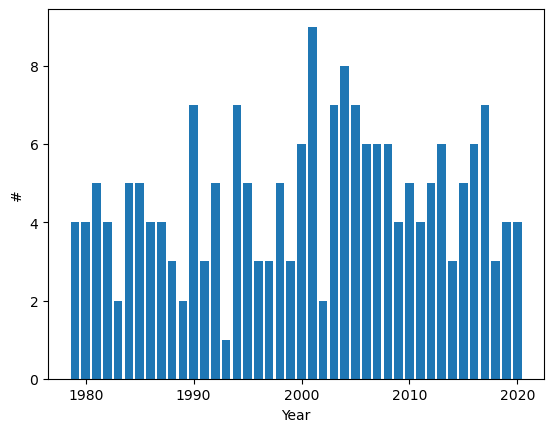

In [5]:
histogram_x, histogram_y = np.unique(np.array(years), return_counts=True)
plt.bar(histogram_x, histogram_y)
plt.ylabel("#")
plt.xlabel("Year")

In [6]:
############################################################################################################
# IBTracks
############################################################################################################

In [7]:
# trigger the latest downlaod with a random storm_id
_ = TCTracks.from_ibtracs_netcdf(storm_id="1979174N07143")

In [8]:
ibtracks = xr.open_dataset("/lfs/home/yanlan/climada/data/IBTrACS.ALL.v04r01.nc")
ibtracks # Coordinates ≈ Data variables

<xarray.Dataset> Size: 4GB
Dimensions:           (storm: 13597, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 39MB ...
    lat               (storm, date_time) float32 20MB ...
    lon               (storm, date_time) float32 20MB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/159)
    numobs            (storm) float32 54kB ...
    sid               (storm) |S13 177kB ...
    season            (storm) float32 54kB ...
    number            (storm) int16 27kB ...
    basin             (storm, date_time) |S2 10MB ...
    subbasin          (storm, date_time) |S2 10MB ...
    ...                ...
    reunion_gust      (storm, date_time) float32 20MB ...
    reunion_gust_per  (storm, date_time) float32 20MB ...
    usa_seahgt        (storm, date_time) float32 20MB ...
    usa_searad        (storm, date_time, quadrant) float32 78MB ...
    storm_speed       (storm, date_time) float32 20MB ...
    storm_dir         (storm, date_time) float32 20MB ...
Attributes: (12/49)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r01
    ...                         ...
    history:                    Sun Sep 20 05:14:12 2026: ncks --no_abc --cnk...
    license:                    These data may be redistributed and used with...
    featureType:                trajectory
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    NCO:                        netCDF Operators version 5.0.7 (Homepage = ht...

In [9]:
############################################################################################################
# IBTracks limited to WP AND year >= 1979
############################################################################################################

In [10]:
min_year = min(years) # 1979
wp_mask = (ibtracks["basin"] == b"WP").any(dim="date_time")
year_mask = ibtracks["season"] >= min_year

ibtracks_wp = ibtracks.isel(storm=wp_mask & year_mask)
ibtracks_wp

<xarray.Dataset> Size: 438MB
Dimensions:           (storm: 1567, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 5MB ...
    lat               (storm, date_time) float32 2MB ...
    lon               (storm, date_time) float32 2MB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/159)
    numobs            (storm) float32 6kB ...
    sid               (storm) |S13 20kB ...
    season            (storm) float32 6kB 1.979e+03 1.979e+03 ... 2.026e+03
    number            (storm) int16 3kB ...
    basin             (storm, date_time) |S2 1MB b'WP' b'WP' b'WP' ... b'' b''
    subbasin          (storm, date_time) |S2 1MB ...
    ...                ...
    reunion_gust      (storm, date_time) float32 2MB ...
    reunion_gust_per  (storm, date_time) float32 2MB ...
    usa_seahgt        (storm, date_time) float32 2MB ...
    usa_searad        (storm, date_time, quadrant) float32 9MB ...
    storm_speed       (storm, date_time) float32 2MB ...
    storm_dir         (storm, date_time) float32 2MB ...
Attributes: (12/49)
    title:                      IBTrACS - International Best Track Archive fo...
    summary:                    The intent of the IBTrACS project is to overc...
    source:                     The original data are tropical cyclone positi...
    Conventions:                ACDD-1.3
    Conventions_note:           Data are nearly CF-1.7 compliant. The sole is...
    product_version:            v04r01
    ...                         ...
    history:                    Sun Sep 20 05:14:12 2026: ncks --no_abc --cnk...
    license:                    These data may be redistributed and used with...
    featureType:                trajectory
    cdm_data_type:              Trajectory
    comment:                    The tracks of TCs generally look like a traje...
    NCO:                        netCDF Operators version 5.0.7 (Homepage = ht...

In [11]:
############################################################################################################
# select the 197 historicals 
############################################################################################################

In [12]:
from collections import defaultdict

storm_lookup = defaultdict(list)

for i in range(ibtracks_wp.sizes["storm"]):

    year = int(ibtracks_wp["season"][i].item())
    name = ibtracks_wp["name"][i].item().decode()
    
    storm_lookup[(year, name)].append(i)

In [13]:
assert ibtracks_wp.sizes["storm"] == sum(len(v) for v in storm_lookup.values())

In [14]:
############################################################################################################
# check naming errors
############################################################################################################

In [15]:
for f in tracks_list:
    year_number_name = Path(f).stem.split("_")[1] # 197901ELLIS

    year = int(year_number_name[:4])
    name = year_number_name[6:]

    if (year, name) not in storm_lookup:
        print("Missing in IBTracks:", (year, name))
        print("Possible IBTrACS names:", ", ".join(n for y, n in storm_lookup if y == year))
        print("-" * 100)

Missing in IBTracks: (1980, 'BELLY')
Possible IBTrACS names: UNNAMED, CARMEN, DOM, ELLEN, FORREST, GEORGIA, HERBERT, IDA, JOE, KIM, LEX, MARGE, NORRIS, ORCHID, RUTH, SPERRY, PERCY, THELMA, VERNON, WYNNE, ALEX, BETTY, CARY, DINAH, ED
----------------------------------------------------------------------------------------------------
Missing in IBTracks: (1985, 'BRENDA')
Possible IBTrACS names: FABIAN, ELSIE, UNNAMED, GAY, HAL, IRMA, JEFF, KIT, LEE, MAMIE, NELSON, ODESSA, PAT, RUBY, TESS, SKIP, VAL, WINONA, ANDY, BRENDAN, CECIL, DOT, ELLIS, FAYE, GORDON, HOPE, IRVING
----------------------------------------------------------------------------------------------------


In [16]:
name_fixes = {
              "BELLY": "BETTY",
              "BRENDA": "BRENDAN"
             }

idx = []

for f in tracks_list:
    
    year_number_name = Path(f).stem.split("_")[1] # 197901ELLIS
    year = int(year_number_name[:4])
    name = year_number_name[6:] 
    name = name_fixes.get(name, name) # neat!


    with open(f) as example_file:
        all_rows = example_file.readlines()

    first_row = all_rows[0].split()
    last_row = all_rows[-1].split()

    time_first = np.datetime64(
        f"{first_row[1]}-{first_row[2]}-{first_row[3]}T{first_row[4]}:00")
    
    time_last = np.datetime64(
        f"{last_row[1]}-{last_row[2]}-{last_row[3]}T{last_row[4]}:00")


    if len(storm_lookup[(year, name)]) > 1:

        storm_lookup[(year, name)] = [i for i in storm_lookup[(year, name)]
                                      if (
                                        ibtracks_wp["time"][i].dropna("date_time").values.min() <= time_first
                                        and
                                        ibtracks_wp["time"][i].dropna("date_time").values.max() >= time_last
                                        )
                                     ]


    
    assert len(storm_lookup[(year, name)]) == 1
       
    idx.extend(storm_lookup[(year, name)])

In [17]:
assert len(idx) == len(tracks_list)

In [18]:
ibtracks_wp_197 = ibtracks_wp.isel(storm=idx) 

In [19]:
############################################################################################################
# "ib_all_tracks_haz"
############################################################################################################

In [20]:
ibtracks_197_id = ibtracks_wp_197.sid.values.astype(str).tolist()
ib_all_tracks = TCTracks.from_ibtracs_netcdf(storm_id=ibtracks_197_id)
############################################################################################################
# centroids = from WRF
lat_min, lat_max = 20.0, 29.0
lon_min, lon_max = 117.0, 126.0

files_list = sorted(glob.glob("/lfs/home/yanlan/climada/tc-risk/PGW4K.v230926/wrfout_d01_*_48.nc"))

with xr.open_dataset(files_list[0]) as ref:

    # mask is of xarray.DataArray
    mask = (
            (ref["XLAT"].isel(Time=0)>=lat_min) & (ref["XLAT"].isel(Time=0)<=lat_max) &
            (ref["XLONG"].isel(Time=0)>=lon_min) & (ref["XLONG"].isel(Time=0)<=lon_max)
           ) 

    centroids = Centroids(
                          lat=ref["XLAT"].isel(Time=0).values.ravel()[mask.values.ravel()],
                          lon=ref["XLONG"].isel(Time=0).values.ravel()[mask.values.ravel()]
                         )
############################################################################################################
# other Hazard variables 
# ...
############################################################################################################
# other Hazard variables  
# ...

In [21]:
ib_all_tracks_haz = TropCyclone.from_tracks(tracks=ib_all_tracks, 
                                            centroids=centroids, # centroids = from WRF
                                            model='H1980', 
                                            model_kwargs={"gradient_to_surface_winds": 0.9},
                                            intensity_thres=0) 

In [22]:
ib_all_tracks_haz.check()

In [23]:
############################################################################################################
# exceedance_intensities
############################################################################################################

In [24]:
cmap = ListedColormap(["#fff7bc",  # 0–10   pale yellow
                       "#fee391",  # 10–20  yellow
                       "#fec44f",  # 20–30  amber
                       "#fe9929",  # 30–35  orange
                       "#ec7014",  # 35–40  dark orange
                       "#cc4c02",  # 40–45  burnt orange
                       "#a63603",  # 45–50  brick
                       "#7f2704",  # 50–55  dark brick
                       "#67000d"]) # 55–60  deep red
                      
cmap.set_bad("lightgray")  

cmap.set_over("#3f0000") 

levels = [0, 10, 20, 30, 35, 40, 45, 50, 55, 60]
 
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=False)

ib_all_tracks_haz.intensity = sparse.csc_matrix(ib_all_tracks_haz.intensity)
exceedance_intensities, label, column_label = ib_all_tracks_haz.local_exceedance_intensity([10, 20, 30, 50]) # given return periods
ib_all_tracks_haz.intensity = sparse.csr_matrix(ib_all_tracks_haz.intensity)

# mask People's Republic of China as nan
shapefile = shapereader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")

world = gpd.read_file(shapefile)

china = world[world.NAME == "China"].geometry.union_all()

china_mask = exceedance_intensities.geometry.within(china)

value_cols = [col for col in exceedance_intensities.columns if col != "geometry"]

exceedance_intensities.loc[china_mask, value_cols] = np.nan

In [25]:
############################################################################################################
# plot exceedance_intensities
############################################################################################################

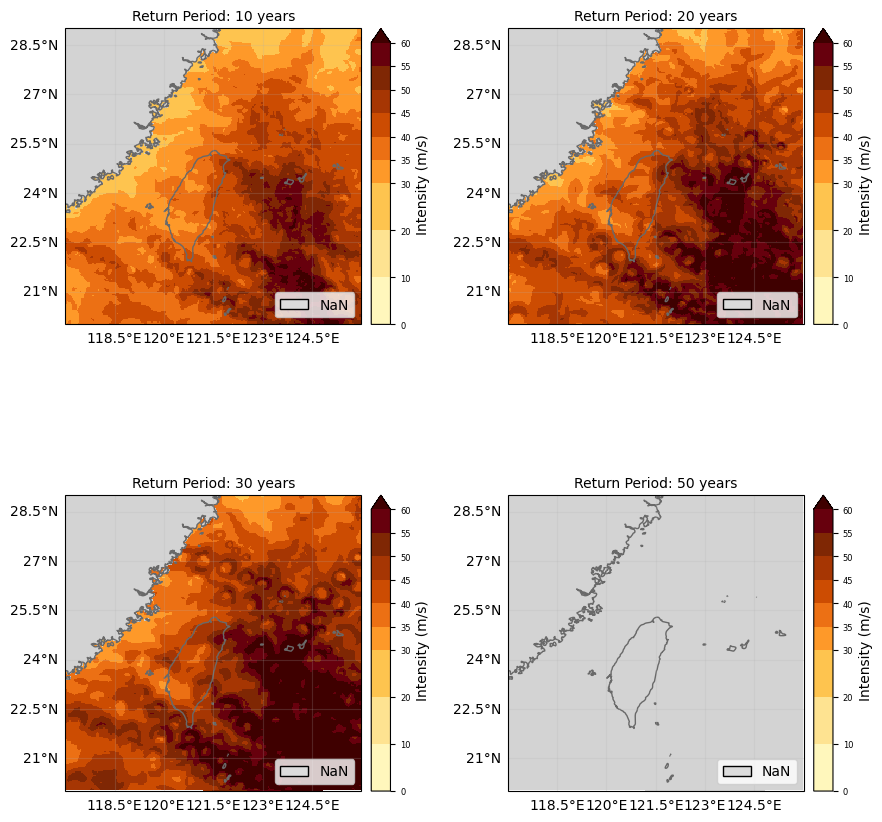

In [26]:
axes = plot_from_gdf(exceedance_intensities,
                     colorbar_name=label,
                     title_subplots=column_label, 
                     cmap=cmap, 
                     norm=norm)

fig = plt.gcf()

map_axes = list(axes.flat)

cbar_axes = [a for a in fig.axes if a not in map_axes]

for map_ax, cax in zip(map_axes, cbar_axes):
    pcolormesh = map_ax.collections[-1]   # the last collection is the data layer
    cax.clear()
   
    fig.colorbar(pcolormesh, 
                 cax=cax, 
                 spacing="proportional", 
                 boundaries=levels, 
                 ticks=levels, 
                 label=label,
                 extend="max")
    
    cax.tick_params(labelsize=6) 

plt.show()

In [27]:
############################################################################################################
# return periods
############################################################################################################

In [28]:
cmap = ListedColormap(["#fff7bc",  # 0–1   pale yellow
                       "#fee391",  # 1–2   yellow
                       "#fec44f",  # 2–3   amber
                       "#fe9929",  # 3–5   orange
                       "#ec7014",  # 5–8   dark orange
                       "#cc4c02",  # 8–12  burnt orange
                       "#a63603",  # 12–17 brick
                       "#7f2704",  # 17–23 dark brick
                       "#67000d"]) # 23–30 deep red
                      
cmap.set_bad("lightgray")

cmap.set_over("#3f0000") 

levels = [0, 1, 2, 3, 5, 8, 12, 17, 23, 30]

norm = BoundaryNorm(levels, ncolors=cmap.N, clip=False)

ib_all_tracks_haz.intensity = sparse.csc_matrix(ib_all_tracks_haz.intensity)
return_periods, label, column_label = ib_all_tracks_haz.local_return_period([10, 15, 20, 25]) # given exceedance intensities
ib_all_tracks_haz.intensity = sparse.csr_matrix(ib_all_tracks_haz.intensity)


# NaN caused by zero exceed_frequency -> infinite (1000000) return period
for threshold in [10, 15, 20, 25]:
    exceed = ib_all_tracks_haz.intensity > threshold

    exceed_frequency = np.asarray(
        exceed.T.dot(ib_all_tracks_haz.frequency)
    ).ravel()

    climada_nan = return_periods[str(threshold)].isna()
    
    return_periods.loc[climada_nan & (exceed_frequency == 0), str(threshold)] = 1000000


# mask People's Republic of China as nan
shapefile = shapereader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")

world = gpd.read_file(shapefile)

china = world[world.NAME == "China"].geometry.union_all()

china_mask = return_periods.geometry.within(china)

value_cols = [col for col in return_periods.columns if col != "geometry"]

return_periods.loc[china_mask, value_cols] = np.nan

In [29]:
############################################################################################################
# plot return periods
############################################################################################################

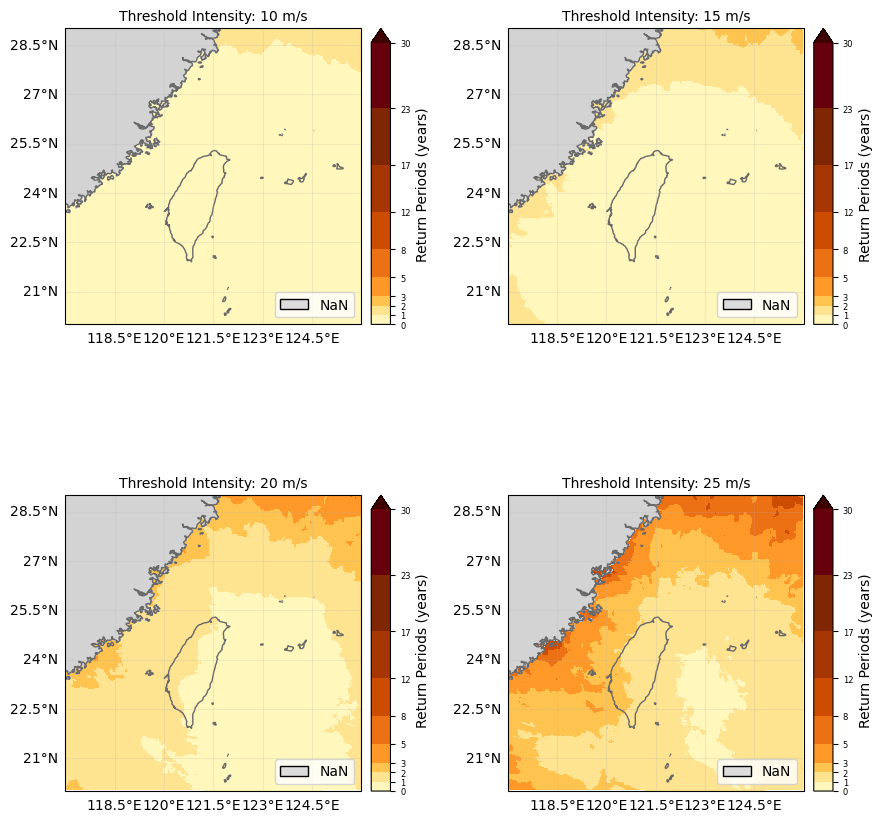

In [30]:
axes = plot_from_gdf(return_periods, 
                     colorbar_name=label, 
                     title_subplots=column_label, 
                     cmap=cmap, 
                     norm=norm)

fig = plt.gcf()

map_axes = list(axes.flat)

cbar_axes = [a for a in fig.axes if a not in map_axes]

for map_ax, cax in zip(map_axes, cbar_axes):
    pcolormesh = map_ax.collections[-1]   # the last collection is the data layer
    cax.clear()
   
    fig.colorbar(pcolormesh, 
                 cax=cax, 
                 spacing="proportional", 
                 boundaries=levels, 
                 ticks=levels, 
                 label=label, 
                 extend="max")
    
    cax.tick_params(labelsize=6) 

plt.show()

In [69]:
############################################################################################################
# the "ib_all_tracks_synth" hazard object 
############################################################################################################

<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
<string>:7: FutureWarning: 'H' is deprecated and will be removed

<GeoAxes: >

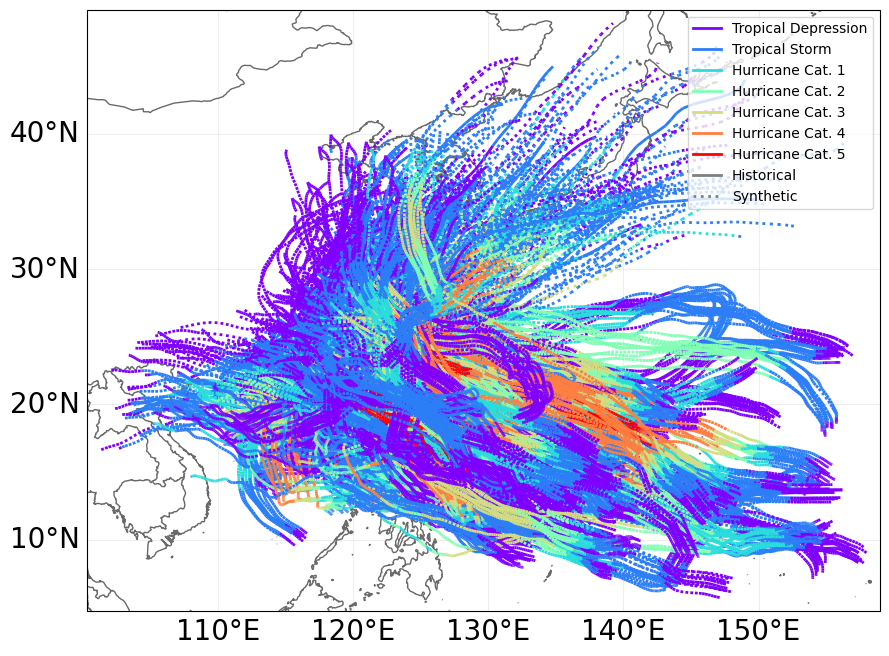

In [41]:
ib_all_tracks.equal_timestep() # must be done before sythetic generation 

# nb_synth_tracks = how many synthetic tracks is computed for every track
# generate synthetic tracks based on directed random walk
ib_all_tracks.calc_perturbed_trajectories(nb_synth_tracks=10) 
                                                           
ib_all_tracks.plot()

In [43]:
# centroids = from WRF
lat_min, lat_max = 20.0, 29.0
lon_min, lon_max = 117.0, 126.0

files_list = sorted(glob.glob("/lfs/home/yanlan/climada/tc-risk/PGW4K.v230926/wrfout_d01_*_48.nc"))

with xr.open_dataset(files_list[0]) as ref:

    # mask is of xarray.DataArray
    mask = (
            (ref["XLAT"].isel(Time=0)>=lat_min) & (ref["XLAT"].isel(Time=0)<=lat_max) &
            (ref["XLONG"].isel(Time=0)>=lon_min) & (ref["XLONG"].isel(Time=0)<=lon_max)
           ) 

    centroids = Centroids(
                          lat=ref["XLAT"].isel(Time=0).values.ravel()[mask.values.ravel()],
                          lon=ref["XLONG"].isel(Time=0).values.ravel()[mask.values.ravel()]
                         )
############################################################################################################
# other Hazard variables 
# ...

In [44]:
ib_all_tracks_synth = TropCyclone.from_tracks(tracks=ib_all_tracks, 
                                              centroids=centroids, # centroids = from WRF
                                              model='H1980', 
                                              model_kwargs={"gradient_to_surface_winds": 0.9},
                                              intensity_thres=0) 

In [45]:
ib_all_tracks_synth.check()

In [46]:
############################################################################################################
# exceedance_intensities
############################################################################################################

In [ ]:
cmap = ListedColormap(["#fff7bc",  # 0–10   pale yellow
                       "#fee391",  # 10–20  yellow
                       "#fec44f",  # 20–30  amber
                       "#fe9929",  # 30–35  orange
                       "#ec7014",  # 35–40  dark orange
                       "#cc4c02",  # 40–45  burnt orange
                       "#a63603",  # 45–50  brick
                       "#7f2704",  # 50–55  dark brick
                       "#67000d"]) # 55–60  deep red
                      
cmap.set_bad("lightgray")  

cmap.set_over("#3f0000") 

levels = [0, 10, 20, 30, 35, 40, 45, 50, 55, 60]
 
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=False)

ib_all_tracks_synth.intensity = sparse.csc_matrix(ib_all_tracks_synth.intensity)
exceedance_intensities, label, column_label = ib_all_tracks_synth.local_exceedance_intensity([10, 20, 30, 50]) # given return periods
ib_all_tracks_synth.intensity = sparse.csr_matrix(ib_all_tracks_synth.intensity)

# mask People's Republic of China as nan
shapefile = shapereader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")

world = gpd.read_file(shapefile)

china = world[world.NAME == "China"].geometry.union_all()

china_mask = exceedance_intensities.geometry.within(china)

value_cols = [col for col in exceedance_intensities.columns if col != "geometry"]

exceedance_intensities.loc[china_mask, value_cols] = np.nan

In [48]:
############################################################################################################
# plot exceedance_intensities
############################################################################################################

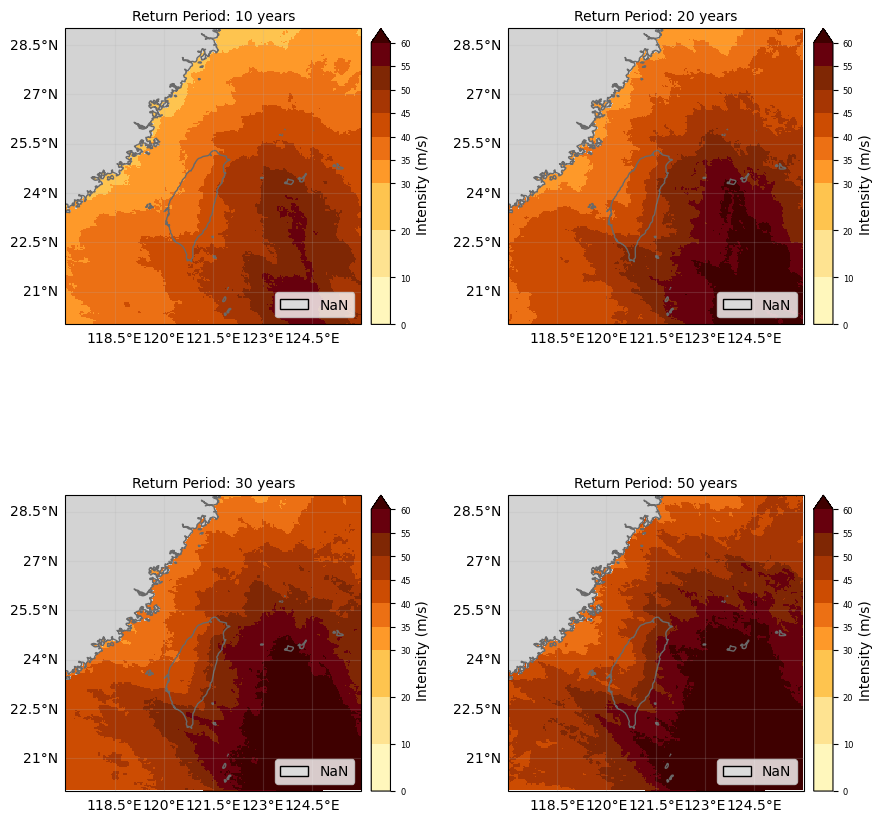

In [49]:
axes = plot_from_gdf(exceedance_intensities,
                     colorbar_name=label,
                     title_subplots=column_label, 
                     cmap=cmap, 
                     norm=norm)

fig = plt.gcf()

map_axes = list(axes.flat)

cbar_axes = [a for a in fig.axes if a not in map_axes]

for map_ax, cax in zip(map_axes, cbar_axes):
    pcolormesh = map_ax.collections[-1]   # the last collection is the data layer
    cax.clear()
   
    fig.colorbar(pcolormesh, 
                 cax=cax, 
                 spacing="proportional", 
                 boundaries=levels, 
                 ticks=levels, 
                 label=label,
                 extend="max")
    
    cax.tick_params(labelsize=6) 

plt.show()

In [ ]:
############################################################################################################
# return periods
############################################################################################################

In [50]:
cmap = ListedColormap(["#fff7bc",  # 0–1   pale yellow
                       "#fee391",  # 1–2   yellow
                       "#fec44f",  # 2–3   amber
                       "#fe9929",  # 3–5   orange
                       "#ec7014",  # 5–8   dark orange
                       "#cc4c02",  # 8–12  burnt orange
                       "#a63603",  # 12–17 brick
                       "#7f2704",  # 17–23 dark brick
                       "#67000d"]) # 23–30 deep red
                      
cmap.set_bad("lightgray")

cmap.set_over("#3f0000") 

levels = [0, 1, 2, 3, 5, 8, 12, 17, 23, 30]

norm = BoundaryNorm(levels, ncolors=cmap.N, clip=False)

ib_all_tracks_synth.intensity = sparse.csc_matrix(ib_all_tracks_synth.intensity)
return_periods, label, column_label = ib_all_tracks_synth.local_return_period([10, 15, 20, 25]) # given exceedance intensities
ib_all_tracks_synth.intensity = sparse.csr_matrix(ib_all_tracks_synth.intensity)


# NaN caused by zero exceed_frequency -> infinite (1000000) return period
for threshold in [10, 15, 20, 25]:
    exceed = ib_all_tracks_synth.intensity > threshold

    exceed_frequency = np.asarray(
        exceed.T.dot(ib_all_tracks_synth.frequency)
    ).ravel()

    climada_nan = return_periods[str(threshold)].isna()
    
    return_periods.loc[climada_nan & (exceed_frequency == 0), str(threshold)] = 1000000


# mask People's Republic of China as nan
shapefile = shapereader.natural_earth(resolution="10m", category="cultural", name="admin_0_countries")

world = gpd.read_file(shapefile)

china = world[world.NAME == "China"].geometry.union_all()

china_mask = return_periods.geometry.within(china)

value_cols = [col for col in return_periods.columns if col != "geometry"]

return_periods.loc[china_mask, value_cols] = np.nan

In [51]:
############################################################################################################
# plot return periods
############################################################################################################

In [ ]:
axes = plot_from_gdf(return_periods, 
                     colorbar_name=label, 
                     title_subplots=column_label, 
                     cmap=cmap, 
                     norm=norm)

fig = plt.gcf()

map_axes = list(axes.flat)

cbar_axes = [a for a in fig.axes if a not in map_axes]

for map_ax, cax in zip(map_axes, cbar_axes):
    pcolormesh = map_ax.collections[-1]   # the last collection is the data layer
    cax.clear()
   
    fig.colorbar(pcolormesh, 
                 cax=cax, 
                 spacing="proportional", 
                 boundaries=levels, 
                 ticks=levels, 
                 label=label, 
                 extend="max")
    
    cax.tick_params(labelsize=6) 

plt.show()